In [1]:
import os
import random
import pickle as pkl
from tqdm import tqdm
import math

from dataclasses import dataclass

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.special import softmax
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import pipeline
import pandas as pd

from personal_llm.utils import *
from scipy.stats import dirichlet

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import matplotlib.pylab as plt


In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report
import string
from nltk.corpus import stopwords

# Download NLTK resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Download additional NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/tpz2105/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/tpz2105/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/tpz2105/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
def get_semantic_scores(args):
    response_quality = "best"

    feature_list = []
    final_features = []

    # formality
    # Use a pipeline as a high-level helper
    formality_path = "../data/formality_{}_scores.npy".format(response_quality)
    formality_scores = np.load(formality_path).T
    print("formality scores", formality_scores.shape)

    feature_list.append("formality")
    final_features.append(formality_scores)


    edu_path = "../data/edu_{}_scores.npy".format(response_quality)

    edu_scores = np.load(edu_path).T
    print("edu scores", edu_scores.shape)

    feature_list.append("educational")
    final_features.append(edu_scores)

    # emotion 
    # https://huggingface.co/arpanghoshal/EmoRoBERTa
    target_emotions = ["approval", "caring", "excitement", "joy", "optimism"]
    pipe = None
    for emotion in target_emotions:
        emo_path = "../data/emotion_{}_{}_scores.npy".format(emotion, response_quality)

        emo_scores = np.load(emo_path).T
        print(emotion, "scores", emo_scores.shape)


        feature_list.append(emotion)
        final_features.append(emo_scores)


    semantic_scores = np.stack(final_features, axis=-1)

    print("\n\nfeature list", feature_list)
    print("ff", semantic_scores.shape)

    return feature_list, semantic_scores

In [4]:
def get_person_choices(w_person, data, reward_models, n_response, rank_ind=0):

    person_choices = []
    for i in range(len(data)):

        row = data.iloc[i]
        item_scores = []
        for rm_idx, rm in enumerate(reward_models):
            rm_scores = []
            for j in range(n_response):
                score = row["response_{}_{}".format(j+1, rm)]
                rm_scores.append(score)
            # if args.softmax:
            #     rm_scores = softmax(np.array(rm_scores)) * w_person[rm_idx]
            # else:
            #     rm_scores = np.array(rm_scores) * w_person[rm_idx]
            rm_scores = np.array(rm_scores) * w_person[rm_idx]
            item_scores.append(rm_scores)

        item_scores = np.array(item_scores)
        item_scores = np.sum(item_scores, 0)
        sorted_ind = np.argsort(-item_scores)
        # print("sorted ind", sorted_ind)
        # print("argmin", np.argmin(item_scores))
        # print("argmax", np.argmax(item_scores))
        # e += 7
        person_choices.append(sorted_ind[rank_ind])
        # if args.worst_response:
            # person_choices.append()
        # else:
            # person_choices.append(np.argmax(item_scores))

    return person_choices
 

In [6]:
@dataclass
class Args:
    seed: int=0
    alpha: float=0.05
    n_persons: int=1000
    quantity_on_hand: int = 0
    worst_response: bool=False
    softmax: bool=False
    n_response: int=8


args = Args()

In [7]:
np.random.seed(args.seed)
random.seed(args.seed)
torch.manual_seed(args.seed)

_, reward_models = get_persons_and_reward_models()
_, test_data = get_data()

n_rm = len(reward_models)
alphas = np.array([args.alpha]*n_rm)
print("alphas", alphas)
persons = dirichlet.rvs(alphas, size=args.n_persons, random_state=args.seed)
print("persons", persons.shape)

alphas [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
persons (1000, 10)


In [8]:
args.worst_response = False
response_quality = "best"
if args.worst_response:
    response_quality = "worst"

all_choices = []
for i in range(persons.shape[0]):
    person = persons[i]
    choices = get_person_choices(person, test_data, reward_models, args.n_response, rank_ind=0)

    all_choices.append(choices)
best_choices = np.array(all_choices)
print("best choices", best_choices.shape)

best choices (1000, 1000)


In [9]:
args.worst_response = True
if args.worst_response:
    response_quality = "worst"

all_choices = []
for i in range(persons.shape[0]):
    person = persons[i]
    choices = get_person_choices(person, test_data, reward_models, args.n_response, rank_ind=3)

    all_choices.append(choices)
worst_choices = np.array(all_choices)
print("worst choices", worst_choices.shape)

worst choices (1000, 1000)


In [10]:
feature_list, semantic_scores = get_semantic_scores(args)

formality scores (8, 1000)
edu scores (8, 1000)
approval scores (8, 1000)
caring scores (8, 1000)
excitement scores (8, 1000)
joy scores (8, 1000)
optimism scores (8, 1000)


feature list ['formality', 'educational', 'approval', 'caring', 'excitement', 'joy', 'optimism']
ff (8, 1000, 7)


In [11]:
print(feature_list)
print(semantic_scores.shape)

['formality', 'educational', 'approval', 'caring', 'excitement', 'joy', 'optimism']
(8, 1000, 7)


In [12]:
best_semantic_feat = []
for i in range(persons.shape[0]):
    p_choices = best_choices[i]
    p_choices = p_choices.tolist()
    p_f_scores = semantic_scores[p_choices, np.arange(len(p_choices)), :]
    best_semantic_feat.append(p_f_scores)
best_response_features = np.array(best_semantic_feat)
print(best_response_features.shape)

(1000, 1000, 7)


In [13]:
worst_semantic_feat = []
for i in range(persons.shape[0]):
    p_choices = worst_choices[i]
    p_choices = p_choices.tolist()
    p_f_scores = semantic_scores[p_choices, np.arange(len(p_choices)), :]
    worst_semantic_feat.append(p_f_scores)
worst_response_features = np.array(worst_semantic_feat)
print(worst_response_features.shape)

(1000, 1000, 7)


In [14]:
# SAVE BEST_RESPONSE_FEATURES, WORST_RESPONSE_FEATURES
# SAVE PLOT DATA
with open("semantic_features.pkl", "wb") as f:
    pkl.dump(
        (best_response_features, worst_response_features), 
        f
    )

In [16]:
assert best_response_features.shape == worst_response_features.shape

n_persons = best_response_features.shape[0]
n_examples = best_response_features.shape[1]

test_scores = []
test_weights = []
for i in range(n_persons):
    X_best = best_response_features[i]
    X_worst = worst_response_features[i]
    X = np.concatenate([X_best, X_worst], axis=0)
    y = np.array([1]*(n_examples)+[0]*(n_examples))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
        penalty=None,
        fit_intercept=False))
    ])
      
    pipe.fit(X_train, y_train)  
    test_score = pipe.score(X_test, y_test)
    clf = pipe["classifier"]
    weight = clf.coef_[0]
    test_scores.append(test_score)
    test_weights.append(weight)

test_scores = np.array(test_scores)
test_weights = np.array(test_weights)
print(test_scores.shape, test_weights.shape)
print("min test score", np.min(test_scores))
print("average test score", np.mean(test_scores))
print("max test score", np.max(test_scores))

(1000,) (1000, 7)
min test score 0.46
average test score 0.5301650000000001
max test score 0.6


In [17]:
with open("semantic_weights.pkl", "wb") as f:
    pkl.dump(
        (feature_list, test_weights), 
        f
    )

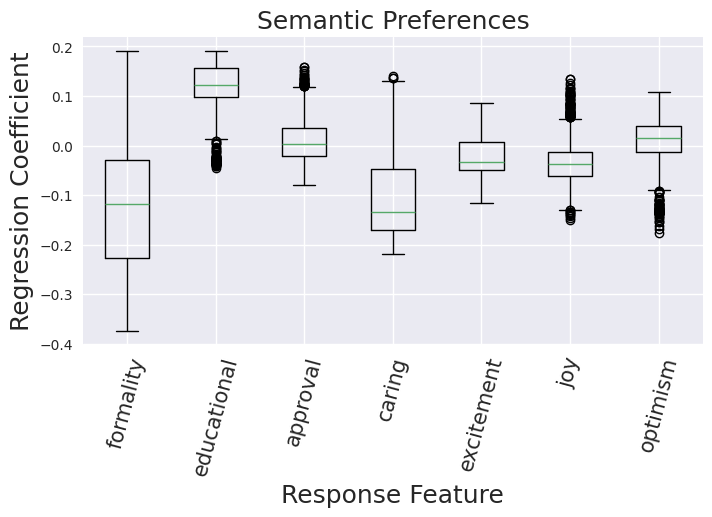

In [18]:
plt.rcParams["figure.figsize"] = (8,4)

data = [test_weights[:,i] for i in range(test_weights.shape[-1])]
plt.boxplot(data)
plt.xticks(np.arange(test_weights.shape[-1])+1, feature_list, fontsize=15, rotation=75)
plt.xlabel("Response Feature", fontsize=18)
plt.ylabel("Regression Coefficient", fontsize=18)

plt.title("Semantic Preferences", fontsize=18)
plt.savefig("../plots/semantic_features.png", bbox_inches="tight", dpi=300)
plt.show()